In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
X = df.iloc[:,1]
y = df.iloc[:,0]

In [7]:
X.head()

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: v2, dtype: str

In [8]:
y.head()

0     ham
1     ham
2    spam
3     ham
4     ham
Name: v1, dtype: str

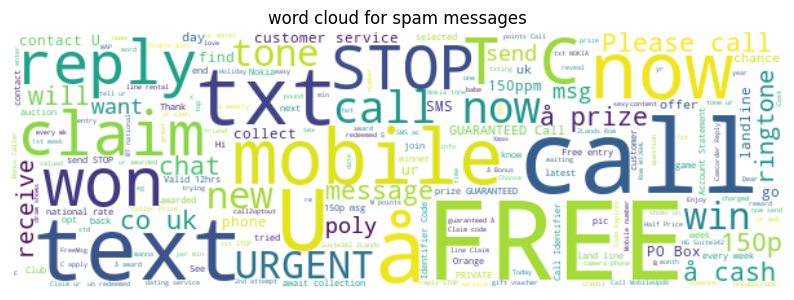

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
spam_text = " ".join(df[df['v1'] == "spam"]['v2'].astype(str))

wordcloud = WordCloud(width=600, height = 200,  background_color = "white", colormap="viridis").generate(spam_text)

# Plot the word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("word cloud for spam messages")
plt.show()

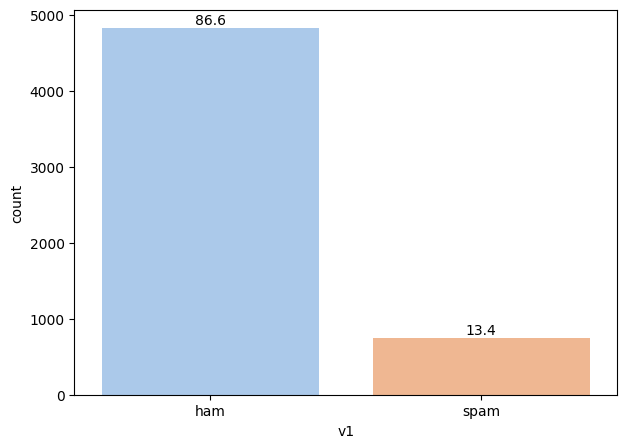

In [10]:
# Visualize the class distribution
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(x="v1", data=df, palette = "pastel",hue="v1")

for p in ax.patches:
    percentage= '{:.1f}'.format(100*p.get_height()/len(X))
    x_countplot = p.get_x()+p.get_width()/2
    y_countplot = p.get_height()+50
    ax.annotate(percentage,(x_countplot,y_countplot),ha = "center")

plt.show()

In [11]:
X_train, X_test,y_train, y_test = train_test_split(X.values.ravel(),y.values.ravel(),
                                                  test_size=0.3,
                                                  random_state=42)

In [12]:
X_train

<StringArray>
[ 'To review and KEEP the fantastic Nokia N-Gage game deck with Club Nokia, go 2 www.cnupdates.com/newsletter. unsubscribe from alerts reply with the word OUT',
                                                                                                                           'Just got outta class gonna go gym.',
                                                                         'Is there coming friday is leave for pongal?do you get any news from your work place.',
 'Hi Dear Call me its urgnt. I don't know whats your problem. You don't want to work or if you have any other problem at least tell me. Wating for your reply.',
                                        'My friend just got here and says he's upping his order by a few grams (he's got $ &lt;#&gt; ), when can you get here?',
                                                                                                                   'Is that on the telly? No its Brdget Jones!',
                    

In [13]:
y_train

<StringArray>
['spam',  'ham',  'ham',  'ham',  'ham',  'ham',  'ham', 'spam',  'ham',
  'ham',
 ...
  'ham',  'ham',  'ham',  'ham',  'ham',  'ham',  'ham',  'ham',  'ham',
  'ham']
Length: 3900, dtype: str

In [14]:
count_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

clf_method = KNeighborsClassifier()
clf_count_vectorizer = Pipeline([
    ("vectorizer", count_vectorizer),
    ("classifier",clf_method)
])
clf_count_vectorizer.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [16]:
clf_tfidf_vectorizer = Pipeline([
    ("vectorizer",tfidf_vectorizer),
    ("classifier",clf_method)
])
clf_tfidf_vectorizer.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [17]:
y_train_pred_cvect = clf_count_vectorizer.predict(X_train)
y_train_tfdif_vect = clf_tfidf_vectorizer.predict(X_train)

print(f'train accruacy using count vectorizer: {accuracy_score(y_train,y_train_pred_cvect)}')
print(f'train accruacy using TF-IDF vectorizer: {accuracy_score(y_train,y_train_tfdif_vect)}')

train accruacy using count vectorizer: 0.9715384615384616
train accruacy using TF-IDF vectorizer: 0.9184615384615384


In [20]:
y_test_pred_cvect = clf_count_vectorizer.predict(X_test)
y_test_tfdif_vect = clf_tfidf_vectorizer.predict(X_test)

print(f'test accruacy using count vectorizer: {accuracy_score(y_test,y_test_pred_cvect)}')
print(f'test accruacy using TF-IDF vectorizer: {accuracy_score(y_test,y_test_tfdif_vect)}')

test accruacy using count vectorizer: 0.9617224880382775
test accruacy using TF-IDF vectorizer: 0.9120813397129187


In [21]:
report = classification_report(y_test, y_test_pred_cvect)
print(report)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1453
        spam       0.98      0.73      0.83       219

    accuracy                           0.96      1672
   macro avg       0.97      0.86      0.91      1672
weighted avg       0.96      0.96      0.96      1672



In [23]:
report = classification_report(y_test,y_test_tfdif_vect)
print(report)

              precision    recall  f1-score   support

         ham       0.91      1.00      0.95      1453
        spam       1.00      0.33      0.49       219

    accuracy                           0.91      1672
   macro avg       0.95      0.66      0.72      1672
weighted avg       0.92      0.91      0.89      1672



In [24]:
cm = confusion_matrix(y_test,y_test_pred_cvect)
cm

array([[1449,    4],
       [  60,  159]])

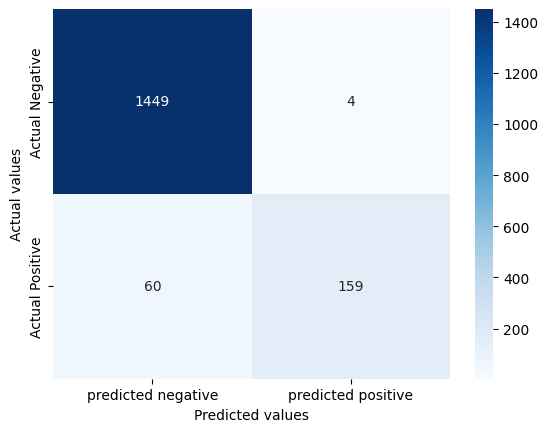

In [28]:
sns.heatmap(cm,annot=True, cmap="Blues", fmt="d",xticklabels=["predicted negative","predicted positive"],
           yticklabels=["Actual Negative","Actual Positive"])
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

In [5]:
# Alternate small code
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


[[1453    0]
 [  67  152]]


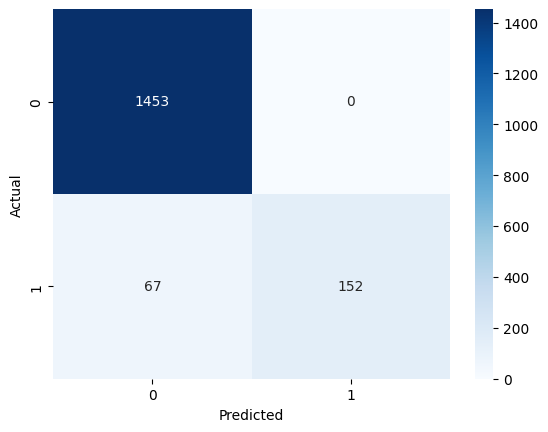

In [9]:
X = df.iloc[:,1]
y = df.iloc[:,0]

X_train, X_test,y_train, y_test = train_test_split(X.values.ravel(),y.values.ravel(),
                                                  test_size=0.3,
                                                  random_state=42)


# 1️⃣ Vectorizer
tfidf_vect = TfidfVectorizer()

X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)   # IMPORTANT

# 2️⃣ Model
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

# 3️⃣ Prediction
y_pred = clf.predict(X_test_tfidf)

# 4️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()